In [11]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

Funzione chi quadro

In [12]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

Importazione

In [13]:
anal,xdata,ydata = gf.importa_pickle("analisi.pkl")

def modello(par, x):
    a,b,d = par
    return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

Creazione array per v, omega e tau

In [14]:
[[v, sv], [omega, s_omega], [tau, s_tau]] = anal
risoluzione = 30
v = np.linspace(v - sv, v + sv, risoluzione)
omega = np.linspace(omega - s_omega, omega + s_omega, risoluzione)
tau = np.linspace(tau - s_tau, tau + s_tau, risoluzione)

### 1. Omega e Tau

In [15]:
O, T = np.meshgrid(omega, tau)
chi_quadri = np.zeros_like(O)

for i in range(O.shape[0]):
    for j in range(O.shape[1]):
        parametri = [anal[0][0], O[i, j], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

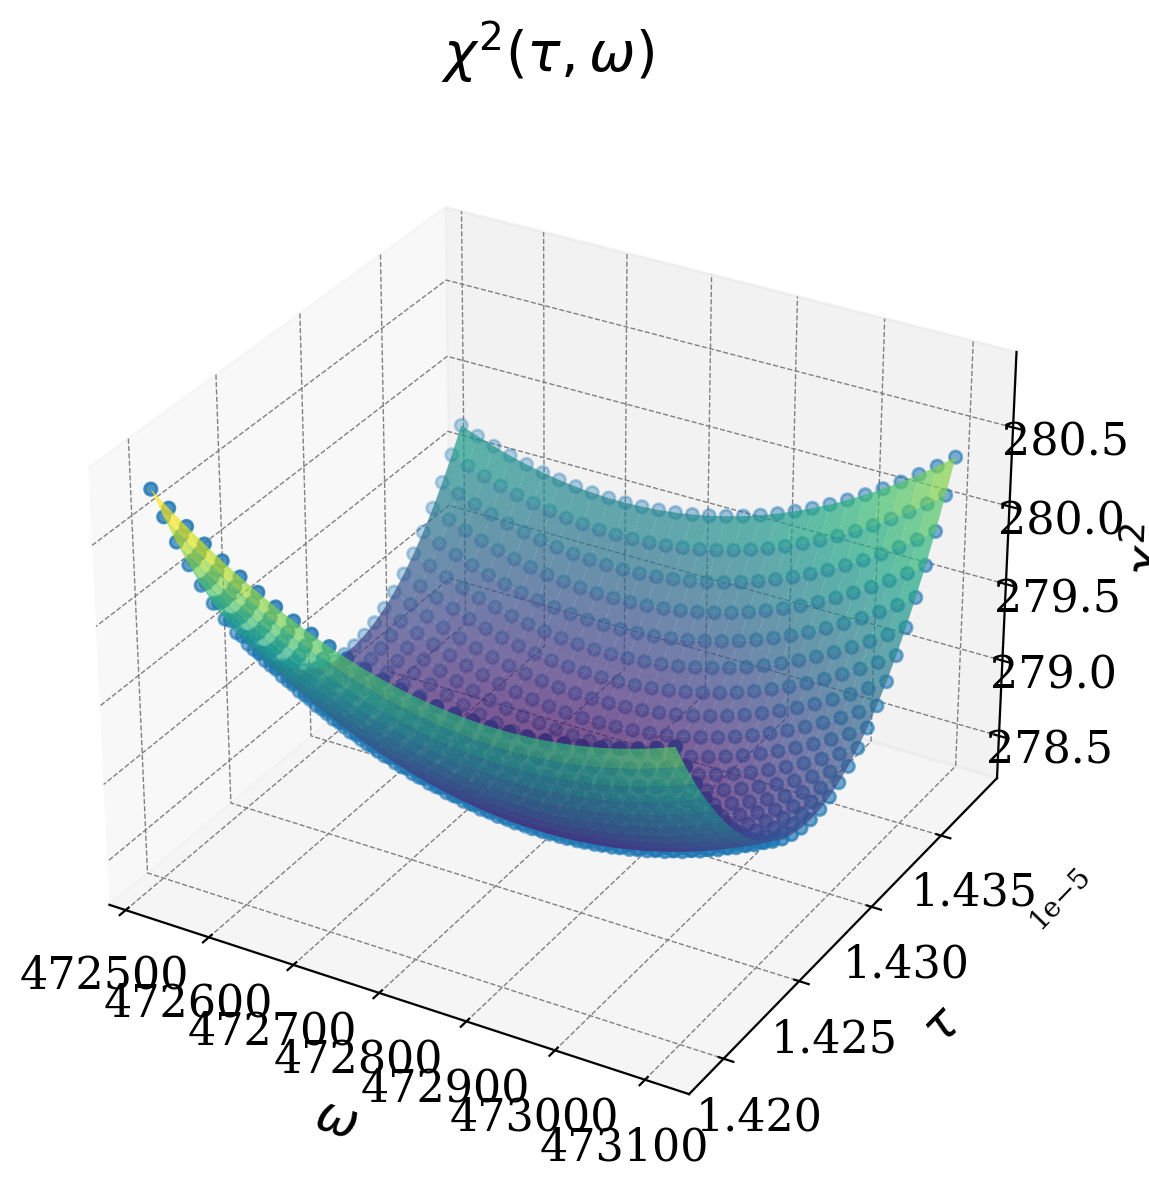

In [16]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
gf.parametri_grafico(ax,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$",zlabel=r"$\chi^2$",tridimensionale=True)

ax.scatter(O, T, chi_quadri)
ax.plot_surface(O, T, chi_quadri, cmap='viridis', alpha=0.7)

gf.salva_grafico(fig,"Chi/omega_tau_3d.pdf")

/tmp/ipykernel_37633/1348889231.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')


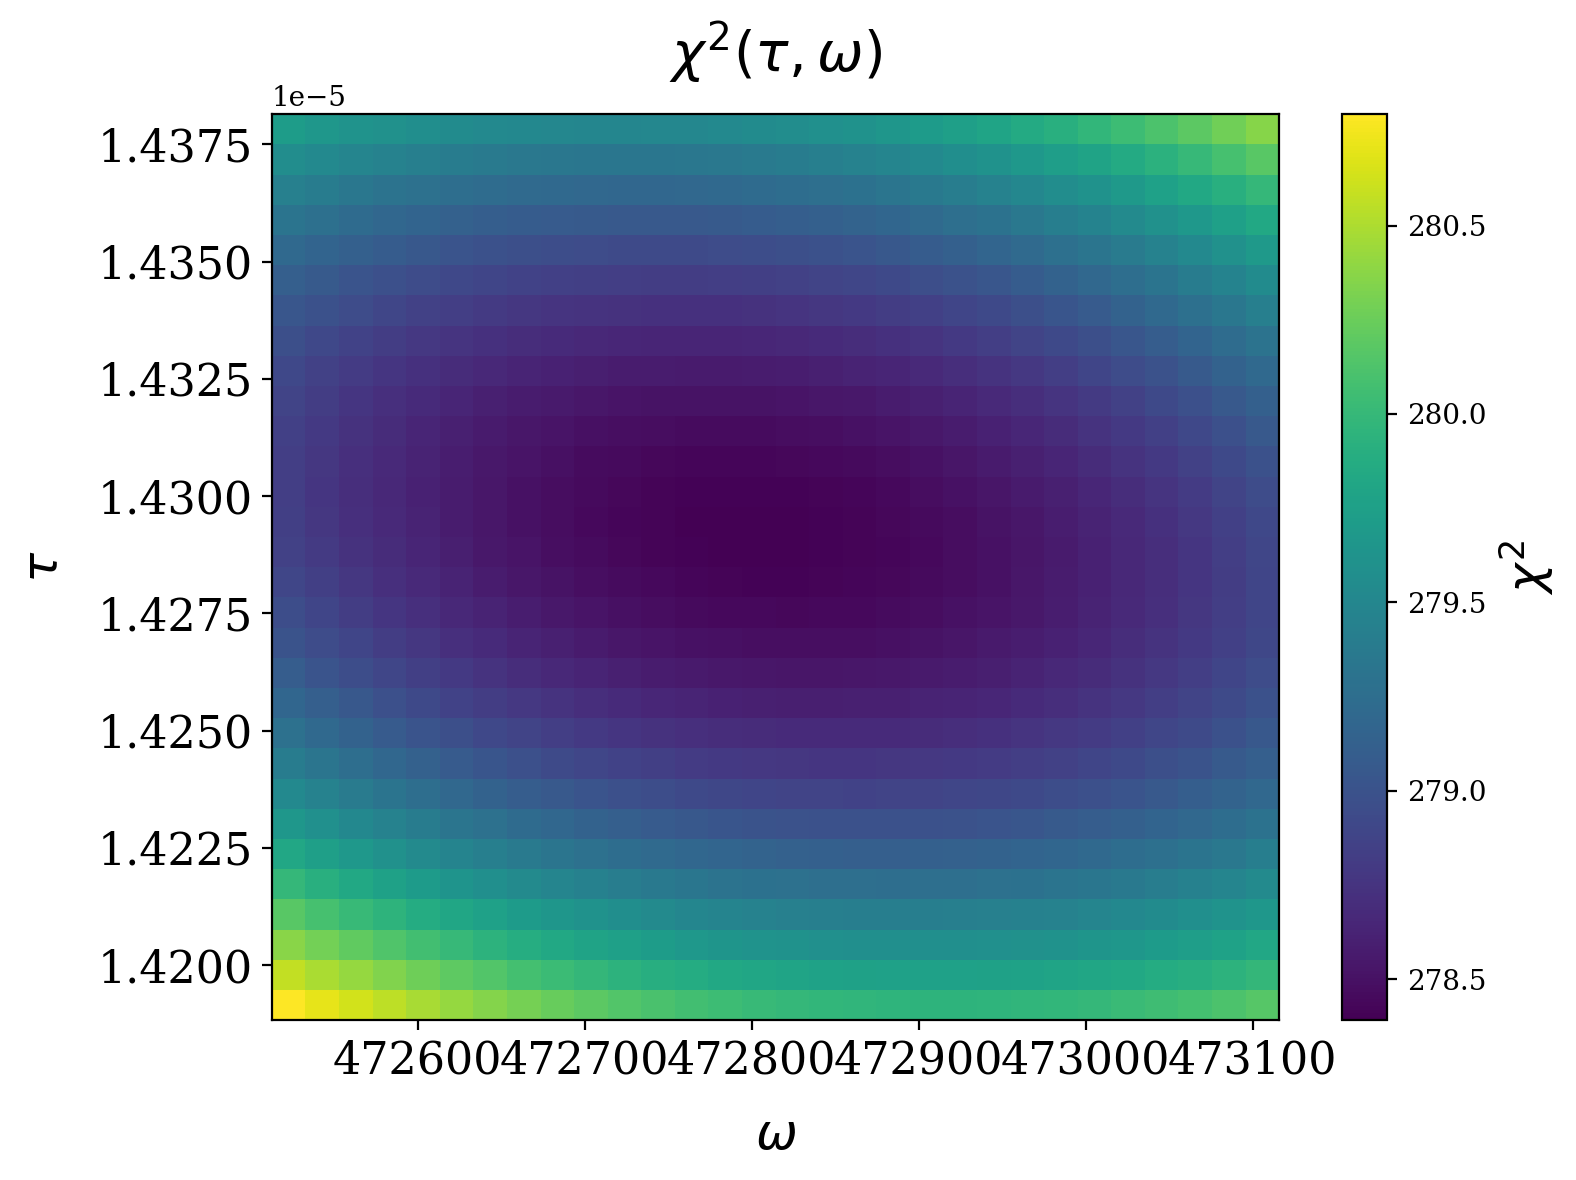

In [17]:
fig, ax = plt.subplots()
gf.parametri_grafico(ax,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$")

colore = ax.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')

fig.colorbar(colore, ax=ax, label=r"$\chi^2$")

gf.salva_grafico(fig,"Chi/omega_tau_2d.pdf")

### 2. V e Tau

In [18]:
V, T = np.meshgrid(v, tau)
chi_quadri = np.zeros_like(V)

for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        parametri = [V[i, j], anal[1][0], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

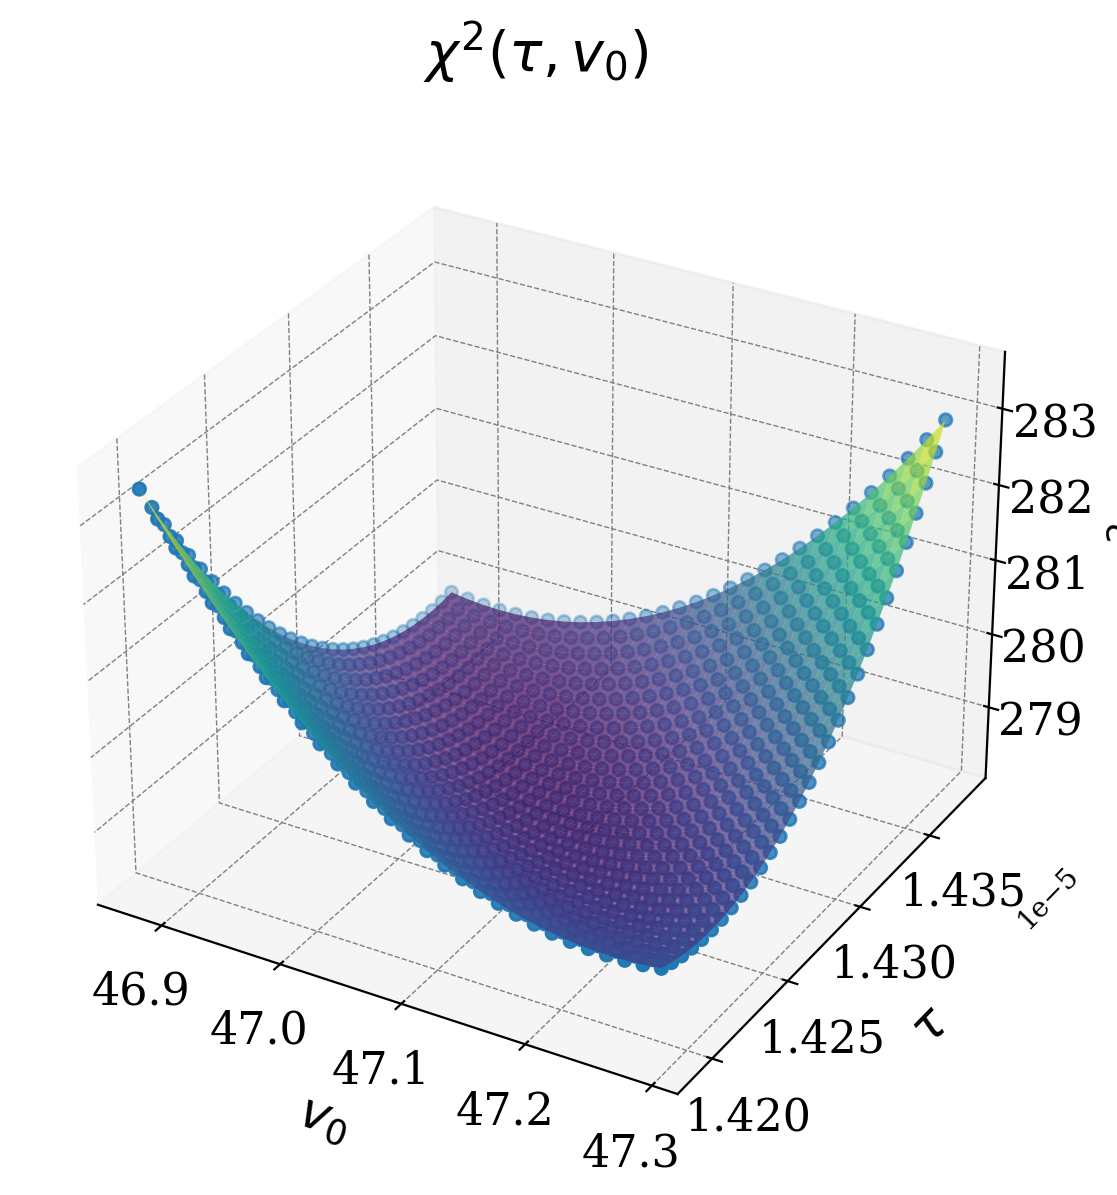

In [19]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
gf.parametri_grafico(ax,r"$\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$",zlabel=r"$\chi^2$",tridimensionale=True)

ax.scatter(V, T, chi_quadri)
ax.plot_surface(V, T, chi_quadri, cmap='viridis', alpha=0.7)

gf.salva_grafico(fig,"Chi/v_tau_3d.pdf")

/tmp/ipykernel_37633/724226969.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax.pcolormesh(V, T, chi_quadri, shading='auto', cmap='viridis')


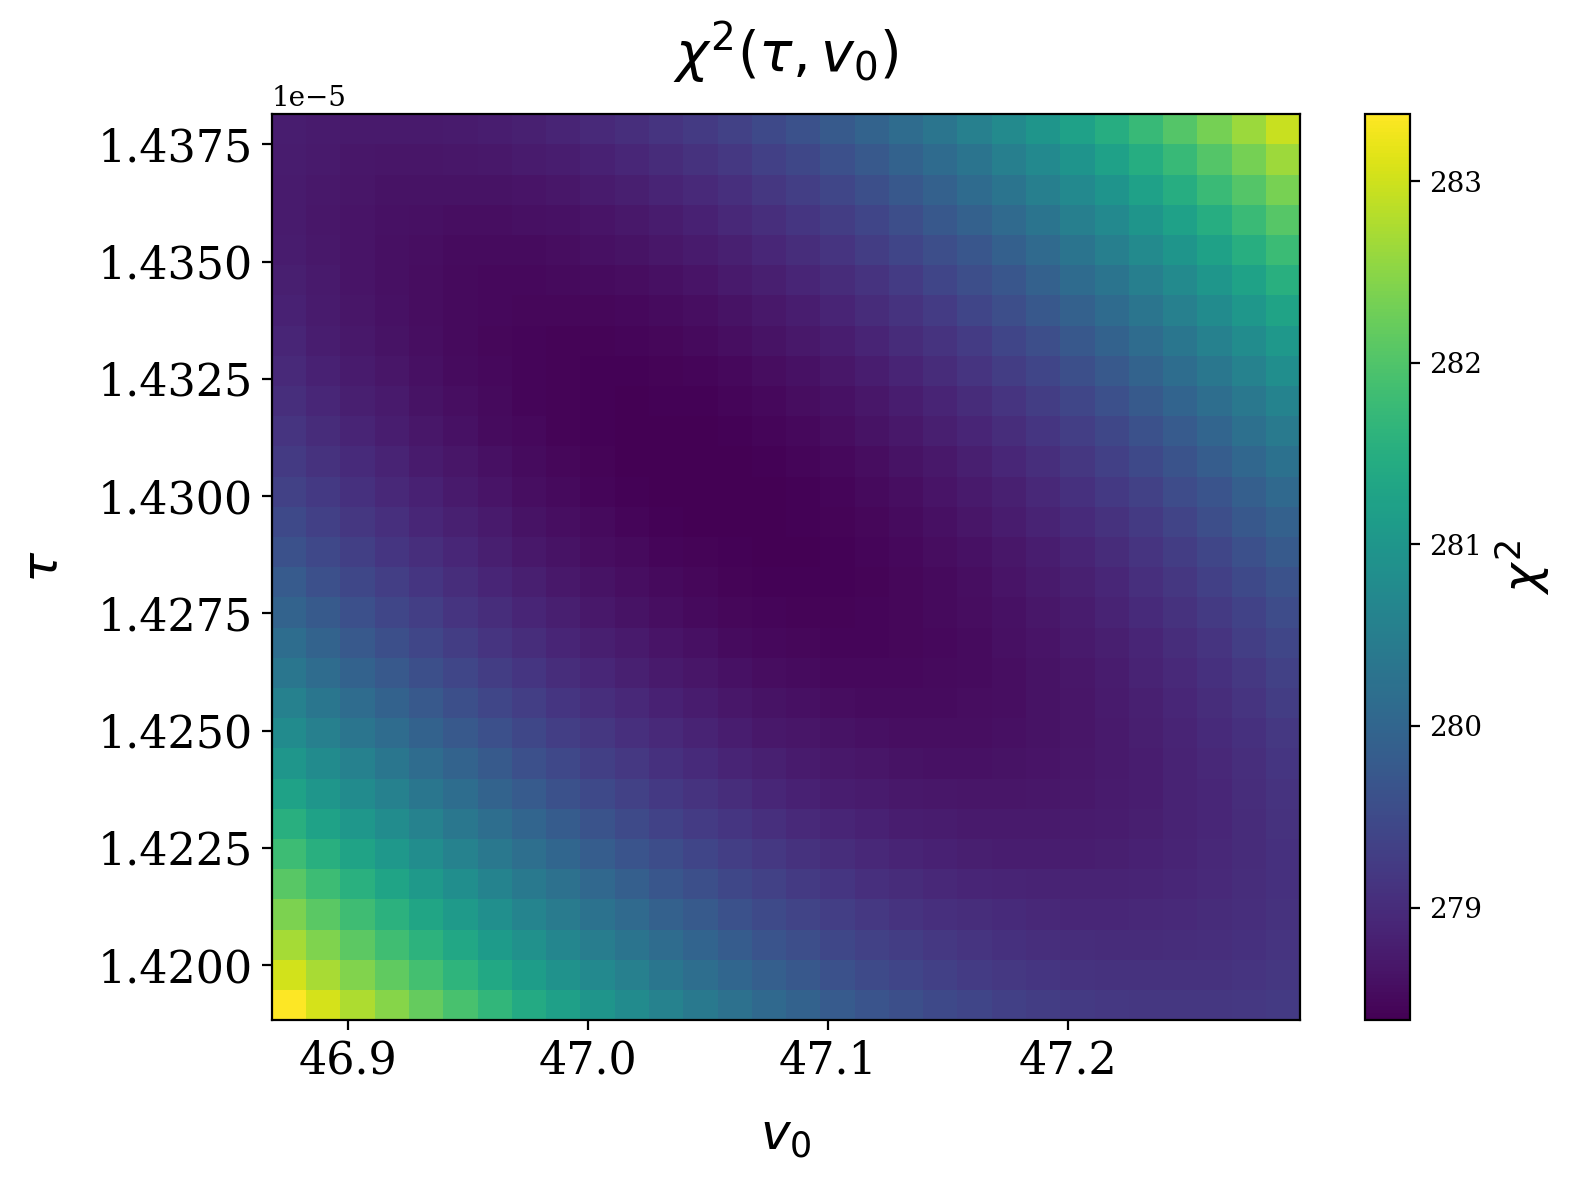

In [20]:
fig, ax = plt.subplots()
gf.parametri_grafico(ax,r"$\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$")

colore = ax.pcolormesh(V, T, chi_quadri, shading='auto', cmap='viridis')

fig.colorbar(colore, ax=ax, label=r"$\chi^2$")

gf.salva_grafico(fig,"Chi/v_tau_2d.pdf")